**NUVEM DE PALAVRAS**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



====== TEXTO PROCESSADO (POSITIVOS) ======

olá sistema bem desenvolvido possui usabilidade excelente parabéns projeto sugestão ter opção restaurar opções velocidade volume tom alterar tom azul interface menos aceso acredito fique confortável achei bem interessante proposta achei ótimo interessante visto algo parecido sistema excelente ferramenta ponto melhoria somente acessibilidade pessoas deficiência visual consigam usar plataforma sistema cumpre bem papel interface simples funcional interessante verificar responsividade sistema dispos ...

====== TEXTO PROCESSADO (NEGATIVOS) ======

geral achei interface fácil utilização contudo alguns momentos achei audiodescrição pouco confusa relação fala personagens tentei realizar ajustes configuração percebi imediatamente alterações posteriormente audiodescrição ficou distorcida senti falta explicações detalhadas tutorial sobre ajustes disponíveis impactos parabéns trabalho fico disposição ajudar avaliações futuras sistema contribui acessibi

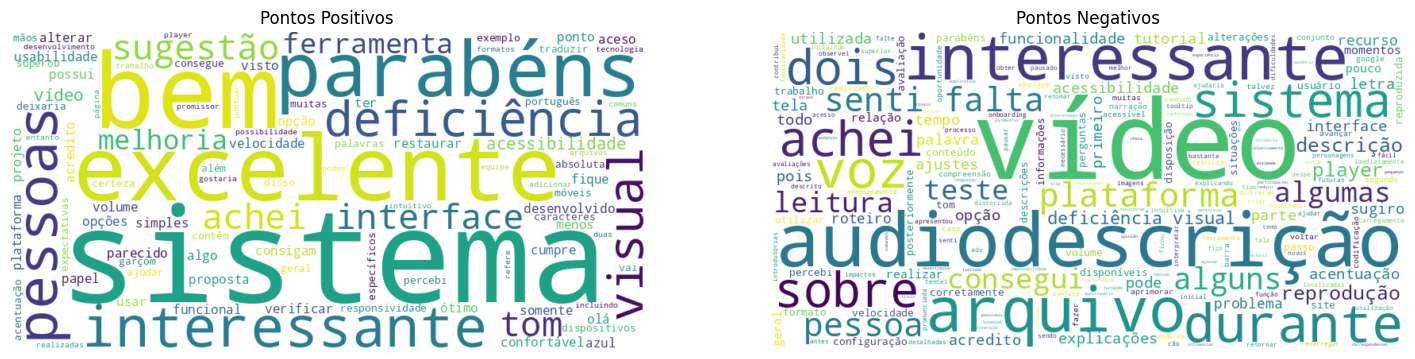

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import string

# baixar recursos
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


# listas originais
respostasPositivas = [ "Olá! O sistema está muito bem desenvolvido e possui uma usabilidade excelente. Parabéns pelo projeto! :)",
"Sugestão: ter uma opção de restaurar as opções de velocidade, volume e tom. Alterar o tom de azul da interface para um menos aceso, acredito que fique mais confortável. Achei bem interessante a proposta.",
"Achei ótimo, interessante, não tinha visto algo parecido com esse sistema.",
"Excelente ferramenta! Como ponto de melhoria somente a acessibilidade para que as pessoas com deficiência visual consigam usar a plataforma.",
"O sistema cumpre muito bem o papel, tem uma interface simples e muito funcional. Seria interessante verificar a responsividade do sistema em dispositivos móveis. Além disso, percebi que o sistema não consegue traduzir muito bem palavras em português que contêm acentuação ou caracteres específicos, por exemplo, mãos e garçom. No geral, o sistema superou muito minhas expectativas! Parabéns!",
"Excelente ferramenta e tenho absoluta certeza de que vai ajudar muitas pessoas com deficiência visual. Só deixaria como sugestão a possibilidade de adicionar mais formatos de arquivos de vídeo, incluindo os mais comuns.",
"Parabéns pelo trabalho da equipe de desenvolvimento.",
"O sistema é intuitivo e muito promissor no que se refere a tecnologia de acessibilidade para pessoas com deficiência visual. No entanto, gostaria de pontuar duas melhorias que podem ser realizadas na página do player de vídeo:",
]

respostasNegativas = [ "No geral achei a interface de fácil utilização. Contudo, em alguns momentos achei a audiodescrição um pouco confusa em relação à fala dos personagens. Tentei realizar ajustes de configuração, mas não percebi imediatamente as alterações e posteriormente a audiodescrição ficou distorcida. Senti falta de explicações mais detalhadas no tutorial sobre os ajustes disponíveis e seus impactos. No mais, parabéns pelo trabalho e fico à disposição para ajudar em avaliações futuras.",
"O sistema contribui muito com a acessibilidade. Senti falta de explicações sobre o formato .adv, incluindo como criar ou obter novos arquivos desse tipo.",
"Não consegui utilizar adequadamente a função de tom. Acredito que falte um onboarding ou explicações sobre as funcionalidades localizadas na parte superior da interface, como velocidade, tom e volume. Um tooltip com informações já ajudaria bastante. No geral, achei a ferramenta intuitiva e interessante.",
"Acredito que o passo a passo do teste poderia ser melhor descrito, explicando primeiro o acesso ao ADVPlayer, a leitura do tutorial e posteriormente o carregamento dos arquivos. Também senti falta de informações introdutórias sobre audiodescrição para usuários sem familiaridade com o tema.",
"O sistema apresentou dificuldades para interpretar corretamente algumas palavras com acentuação, como a palavra cão, que foi pronunciada letra por letra.",
"Ao pausar o vídeo e retornar para a tela inicial, não consegui retomar a reprodução do conteúdo.",
"Durante os testes, observei situações em que a audiodescrição continuou sendo reproduzida mesmo com o vídeo pausado.",
"Quando ocorreram alguns problemas durante a reprodução, foi necessário recarregar o site e reiniciar todo o processo.",
"Em alguns momentos a audiodescrição foi reproduzida antes das imagens correspondentes.",
"Também percebi atraso em determinadas descrições durante a reprodução do vídeo.",
"Como a interação com a interface é relativamente limitada, o conteúdo do vídeo pode influenciar algumas respostas relacionadas à experiência do usuário.",
"Em algumas perguntas do questionário senti falta de uma opção que permitisse indicar ausência de opinião ou impossibilidade de avaliação.",
"Sugiro revisar o tempo estimado de participação informado no TCLE, pois um tempo muito elevado pode desestimular possíveis participantes.",
"Não me senti confortável ao ajustar os níveis do player, pois pequenas alterações resultaram em mudanças muito intensas na voz, tornando a compreensão difícil. Também não consegui realizar esses ajustes em tela cheia.",
"Senti falta de um guia explicativo sobre os parâmetros de configuração disponíveis no sistema.",
"Sugiro reduzir a distância entre o título da barra e os comandos do player, pois a disposição atual pode causar confusão durante o uso.",
"Seria interessante aprimorar a voz sintética para que identifique corretamente palavras com acentuação, melhorando a qualidade da narração.",
"Talvez a possibilidade de alterar a voz utilizada pela audiodescrição fosse uma funcionalidade interessante, caso seja viável implementá-la.",
"Não consegui utilizar a barra deslizante para retroceder ou avançar o vídeo. também notei que a síntese de voz utilizada não pronuncia letras com diacríticos, o que dificulta o entendimento de muitas cenas.",
"Seria interessante Opção de selecionar voz, mais descrições e verificar a linguagem português",
"Comecemos com a parte chata: encontrei dois erros no sistema. O primeiro deles consiste no próprio player, que não permite avançar ou voltar o vídeo pelo teclado nem modificar os volumes do vídeo e da leitura da descrição com o leitor de telas (NVDA não encontrou essas opções). A esse propósito, testei até mesmo o site com dois navegadores, visto que meu primeiro teste foi realizado no Google Chrome e o segundo no Mozilla Firefox. Inclusive, se houvesse uma opção de deixar a descrição mais alta que o vídeo, talvez eu não tivesse a necessidade de voltar o player para entender algumas partes e, possivelmente, nem tivesse identificado essa problemática dos controles de reprodução. O segundo problema, por sua vez, foi observado durante a própria leitura da descrição, visto que a voz da Google leu 'chão' como 'c h o', 'Lúcia' como 'L cia', 'para' como 'p ra', entre outros exemplos. Se não fosse o último caso, que normalmente não possui acentuação gráfica, eu diria que o problema estaria relacionado ao processamento da codificação Unicode. Essa ideia vem de situações semelhantes que enfrento com arquivos UTF-8 dentro do Edivox, cuja leitura só é possibilitada após conversão para uma das variações da codificação UTF-16. No mais, achei interessante a proposta e acredito que seja possível desenvolver muitas funcionalidades com o sistema. Confesso que minhas expectativas envolviam a descrição de qualquer vídeo, mas compreendo que um projeto é construído aos poucos. Não apenas parabenizo os pesquisadores por escolherem a audiodescrição como área de estudo e desenvolvimento tecnológico, mas também agradeço pelo trabalho realizado. Gratidão principalmente à Marcela, que me auxiliou durante os testes. Finalmente, desejo sucesso a todos!",
"A plataforma tem uma questão inovadora, que é oferecer oportunidade de adicionar a audiodescrição em um vídeo. Porém, a visão que tenho é de que a plataforma não oferece vídeos com audiodescrição, ela disponibiliza dois arquivos separados, portanto delegar à pessoa com deficiência visual a união dos dois arquivos não é nada acessível. O interessante seria a plataforma disponibilizar sim o vídeo com recurso de acessibilidade já disponível e não dois arquivos diferentes. Então, sugiro que vocês ofereçam uma plataforma que possibilite a construção de vídeos com audiodescrição. É interessante salientar que o mais complexo é fazer o arquivo de audiodescrição e inseri-lo em um vídeo, e vocês estão fazendo isso, mas dificultando o percurso para as pessoas com deficiência visual. Com relação à avaliação de alguns quesitos do roteiro, desculpem não poder avaliar, essas perguntas devem ser dirigidas a uma pessoa que enxergue e não a uma pessoa com deficiência visual, que não tem como julgar o roteiro em conjunto com a imagem. Achei desnecessária a velocidade utilizada para a locução, havia tempo suficiente para uma narração mais tranquila e pausada, trazendo mais conforto e compreensão. Seria interessante vocês disponibilizarem um tutorial de como se fazer o arquivo desenvolvido para audiodescrição, isso até mesmo daria oportunidade às pessoas com deficiência visual de trabalhar em conjunto com a elaboração de roteiros e produzirem um vídeo com um recurso de acessibilidade em vídeos na plataforma em um formato acessível para todos. Parabéns pela iniciativa e espero que vocês consigam aprimorar o recurso."
   ]


# juntar tudo em um texto único
text1 = " ".join(respostasPositivas)
text2 = " ".join(respostasNegativas)

# stopwords
stop_words = set(stopwords.words("portuguese"))

def preprocess(text):
    # 1. tudo minúsculo
    text = text.lower()

    # 2. remover pontuação
    text = text.translate(str.maketrans("", "", string.punctuation))

    # 3. tokenizar
    tokens = word_tokenize(text)

    # 4. remover stopwords
    tokens = [w for w in tokens if w not in stop_words]

    # 5. juntar de volta para o WordCloud
    return " ".join(tokens)

# aplicar pré-processamento
clean1 = preprocess(text1)
clean2 = preprocess(text2)

print("\n====== TEXTO PROCESSADO (POSITIVOS) ======\n")
print(clean1[:500], "...")   # mostra os primeiros 500 caracteres

print("\n====== TEXTO PROCESSADO (NEGATIVOS) ======\n")
print(clean2[:500], "...")

# gerar WordCloud
wc1 = WordCloud(width=800, height=400, background_color="white").generate(clean1)
wc2 = WordCloud(width=800, height=400, background_color="white").generate(clean2)

# exibir imagens
plt.figure(figsize=(18,6))

plt.subplot(1,2,1)
plt.imshow(wc1, interpolation="bilinear")
plt.axis("off")
plt.title("Pontos Positivos")

plt.subplot(1,2,2)
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Pontos Negativos")

plt.show()

